In [1]:
import matplotlib.pyplot as plt
import numpy as np
from marks import marks
import multiprocessing as mp
import os
from datetime import datetime
import threading
from tqdm import tqdm
import threading
import params as pm

ModuleNotFoundError: No module named 'marks'

In [18]:
#marks_to_consider = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
marks_to_consider = [5, 6, 8, 9]
M = len(marks_to_consider)
N = 7
L = 1
beta = 1.0
n_samples = 100
n_steps = 3_000

params = pm.load('live_params2.npy')
#params = pm.load('live_params_smallrun.npy')

stats_exp = load_exp_stats(marks_to_consider, L, suffix='_bdt3')

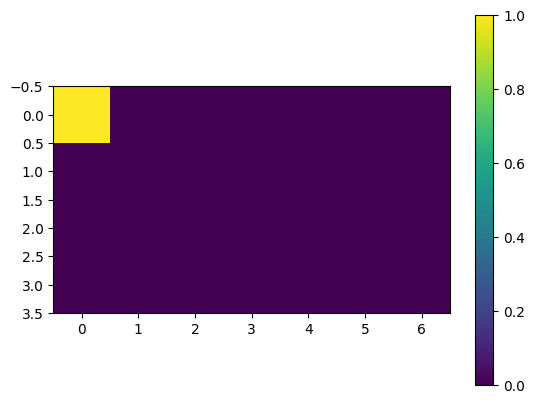

In [19]:
states = [initialize_state_random(M, N, p=stats_exp['means']) for _ in range(n_samples)]
states = [do_mmc_iteration(state, params, beta, n_steps) for state in states]

plt.figure()
plt.imshow(states[0])
plt.colorbar()
plt.show()

stats_sim = get_stats_for_states(states, L)
#update_via_lr(params, stats_sim, stats_exp, lr)
#update_via_lr_and_momentum(params, stats_sim, stats_exp, velocity, lr, momentum)

error, e_parts = get_relative_error(stats_sim, stats_exp)

In [20]:
#np.save(f'states_cbs_small.npy', states)

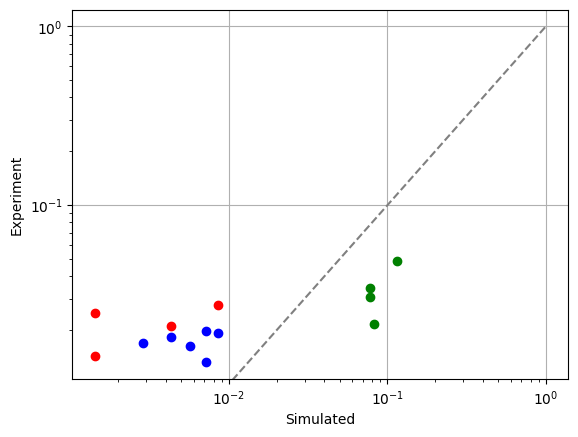

In [21]:
plt.figure()
plt.scatter(stats_sim['means'].flatten(), stats_exp['means'].flatten(), color='green')
plt.scatter(np.ma.compressed(stats_sim['intra_corr']), np.ma.compressed(stats_exp['intra_corr']), color='blue')
plt.scatter(stats_sim['inter_corr'].flatten(), stats_exp['inter_corr'].flatten(), color='red')
plt.plot([0, 1], [0, 1], color='gray', ls='--')
plt.xlabel('Simulated')
plt.ylabel('Experiment')
plt.grid()
plt.gca().set_axisbelow(True)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [22]:
e, e_parts = get_relative_error(stats_sim, stats_exp)
print('ERR:', np.round(error, 5), ' | mean', np.round(e_parts[0], 5), '| intra_corr', np.round(e_parts[1], 5), '| inter_corr', np.round(e_parts[2], 5))

ERR: 1.09061  | mean 1.59971 | intra_corr 0.6558 | inter_corr 0.82176


In [2]:

def load_exp_stats(marks_to_consider, L, suffix='_all'):
    m = list(marks_to_consider)
    M = len(m)
    return {
        'means': np.load(f'stats/means{suffix}.npy')[m],
        'intra_corr': np.ma.array(np.load(f'stats/intra_corr{suffix}.npy')[m, :][:, m], mask=np.triu(np.ones((M, M)), k=0)),
        'inter_corr': np.load(f'stats/inter_corr{suffix}.npy')[m, :L],
    }


def initialize_params_constant(M, L, c=0):
    return {
        'h': np.zeros(M),
        'J': np.ma.array(np.zeros((M, M)), mask=np.triu(np.ones((M, M)), k=0)),
        'K': np.zeros((M, L))
    }

def initialize_params_via_stats(stats):
    M = stats['intra_corr'].shape[0]
    return {
        'h': -stats['means'].copy(),
        'J': -np.ma.array(stats['intra_corr'].copy(), mask=np.triu(np.ones((M, M)), k=0)),
        'K': -stats['inter_corr'].copy()
    }


def get_state_energy(state, params):
    L = params['K'].shape[1]
    N = state.shape[1]
    E_h = np.sum(params['h'] * state.T)
    E_J = np.sum(params['J'] * np.sum(state.T[:, :, None] * state.T[:, None, :], axis=0))
    pre = [[(i + l) % N for i in range(N)] for l in range(1, L+1)]
    E_K = np.sum([np.sum(params['K'][:, l-1][:, np.newaxis] * state[:, pre[l-1]] * state[:, :]) for l in range(1, L+1)])
    return E_h + E_J + E_K


def initialize_state_constant(M, N, c=0):
    return np.zeros((M, N), dtype=np.uint8) + c

def initialize_state_random(M, N, p=None):
    state = np.empty((M, N), dtype=np.uint8)
    for m in range(M):
        state[m, :] = np.random.choice(a=[0, 1], size=N, p=(1-p[m], p[m]))
    return state


def print_state(state):
    print(''.join(['_' for _ in range(state.shape[1])]))
    for row in state:
        print(''.join(map(lambda x: '@' if x==1 else ' ', row)))
    print(''.join(['¯' for _ in range(state.shape[1])]))
    print('')

def get_state_means(state):
    return np.mean(state, axis=1)

def get_state_intra_corr(state):
    M = state.shape[0]
    c = np.zeros((M, M))
    for i in range(M):
        for j in range(i):
            c[i, j] = np.mean(state[i, :] * state[j, :])
    return np.ma.array(c, mask=np.triu(np.ones((M, M)), k=0))

def get_state_inter_corr(state, L):
    M = state.shape[0]
    tmp = np.empty((M, L), dtype=float)
    shift = [[(i + l) % N for i in range(N)] for l in range(1, L+1)]
    for i in range(M):
        for l in range(1, L+1):
            tmp[i, l-1] = np.mean(state[i, shift[l-1]] * state[i, :])
    return tmp

def get_inter_corr_for_states(states, L):
    M = states[0].shape[0]
    tmp = np.empty((M, L), dtype=float)
    shift = [[(i + l) % N for i in range(N)] for l in range(1, L+1)]
    for l in range(1, L+1):
        fence_right = np.concatenate([state[:, shift[l-1]] for state in states], axis=1)
        fence_left = np.concatenate([state[:, :] for state in states], axis=1)
        for i in range(M):
            tmp[i, l-1] = np.mean(fence_right[i] * fence_left[i])
    return np.nan_to_num(tmp)

def get_state_stats(state, L):
    return {
        'means': get_state_means(state),
        'intra_corr': get_state_intra_corr(state),
        'inter_corr': get_state_inter_corr(state, L),
    }

def get_stats_for_states(states, L):
    scarf = np.concatenate(states, axis=1)
    return {
        'means': get_state_means(scarf),
        'intra_corr': get_state_intra_corr(scarf),
        'inter_corr': get_inter_corr_for_states(states, L),
    }


def get_relative_error(stats_sim, stats_exp):
    e = 0
    e_means = np.sum(np.abs(stats_sim['means'] - stats_exp['means']))
    e_intra_corr = np.sum(np.abs(stats_sim['intra_corr'] - stats_exp['intra_corr']))
    e_inter_corr = np.sum(np.abs(stats_sim['inter_corr'] - stats_exp['inter_corr']))
    e = e_means + e_intra_corr + e_inter_corr
    exp_total = (np.sum(stats_exp['means']) + np.sum(stats_exp['intra_corr']) + np.sum(stats_exp['inter_corr']))
    if exp_total != 0:
        e /= exp_total
    else:
        e =0
    return e, (e_means / np.sum(stats_exp['means']), e_intra_corr / np.sum(stats_exp['intra_corr']), e_inter_corr / np.sum(stats_exp['inter_corr']))

def copy_numpy_dict(d):
    r = {}
    for i in d:
        r[i] = d[i].copy()
    return r


#def reduce_stats(statss):
#  r = {}
#  for key in ['means', 'intra_corr', 'inter_corr']:
#    r[key] = np.mean([stats[key] for stats in statss], axis=0)
#  return r


def do_mmc_iteration(state, params, beta, n_steps = 10_000):
    try:
        E_old = get_state_energy(state, params)
        r = np.random.rand(n_steps)
        M, N = state.shape
        for i in range(n_steps):
            m = np.random.randint(0, M)
            n = np.random.randint(0, N)
            ex = E_old
            state[m, n] = 1 - state[m, n]
            E_new = get_state_energy(state, params)
            E_diff = E_new - E_old
            if E_diff < 0 or np.exp(-E_diff * beta) > r[i]:
                E_old = E_new
            else:
                state[m, n] = 1 - state[m, n] # reverse
        return state
    
    except KeyboardInterrupt:
        return

def lsf(l):
    return '['+' '.join(["{:>7}".format(x) for x in np.round(l, 3)])+']'

def update_via_lr(params, stats_sim, stats_exp, lr):
    params['h'] += lr * (stats_sim['means'] - stats_exp['means'])
    params['J'] += lr * (stats_sim['intra_corr'] - stats_exp['intra_corr'])
    params['K'] += lr * (stats_sim['inter_corr'] - stats_exp['inter_corr'])

def update_via_lr_and_momentum(params, stats_sim, stats_exp, velocity, lr, momentum):
    params_prev = copy_numpy_dict(params)
    params['h'] = lr * (stats_sim['means'] - stats_exp['means']) + velocity['h']
    params['J'] = lr * (stats_sim['intra_corr'] - stats_exp['intra_corr']) + velocity['J']
    params['K'] = lr * (stats_sim['inter_corr'] - stats_exp['inter_corr']) + velocity['K']
    for key in ['h', 'J', 'K']:
        velocity[key] = params[key] + momentum * (params[key] - params_prev[key])

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import multiprocessing as mp
import os
from datetime import datetime
import threading
from tqdm import tqdm
import params as pm

import sys

# Add the directory containing params.py to the Python path
sys.path.append('/path/to/params/')

import params as pm  # Now you should be able to import params

# Marks to consider
marks_to_consider = [5, 6, 8, 9]
M = len(marks_to_consider)
N = 7
L = 1
beta = 1.0
n_samples = 100
n_steps = 3_000

# Load parameters
try:
    params = pm.load('live_params2.npy')  # Make sure the file exists
except FileNotFoundError:
    print("Parameter file not found. Please check the file path.")
    params = None

# Load experimental statistics
try:
    stats_exp = load_exp_stats(marks_to_consider, L, suffix='_bdt3')
except FileNotFoundError:
    print("Experimental stats files not found. Please check the file paths.")
    stats_exp = None

# Check if parameters and stats_exp were loaded successfully
if params is not None and stats_exp is not None:
    # Initialize random states
    states = [initialize_state_random(M, N, p=stats_exp['means']) for _ in range(n_samples)]

    # Perform MMC iterations
    states = [do_mmc_iteration(state, params, beta, n_steps) for state in states]

    # Visualize the first state
    plt.figure()
    plt.imshow(states[0], aspect='auto', cmap='viridis')
    plt.colorbar(label='State Value')
    plt.title("First State Visualization")
    plt.show()

    # Calculate simulation statistics
    stats_sim = get_stats_for_states(states, L)

    # Scatter plot for comparing simulated and experimental statistics
    plt.figure()
    plt.scatter(stats_sim['means'].flatten(), stats_exp['means'].flatten(), color='green', label='Means')
    plt.scatter(np.ma.compressed(stats_sim['intra_corr']), np.ma.compressed(stats_exp['intra_corr']), color='blue', label='Intra-Corr')
    plt.scatter(stats_sim['inter_corr'].flatten(), stats_exp['inter_corr'].flatten(), color='red', label='Inter-Corr')
    plt.plot([0, 1], [0, 1], color='gray', ls='--')
    plt.xlabel('Simulated')
    plt.ylabel('Experimental')
    plt.title('Comparison of Simulated and Experimental Statistics')
    plt.grid()
    plt.legend()
    plt.xscale('log')
    plt.yscale('log')
    plt.show()

    # Compute the relative error
    error, e_parts = get_relative_error(stats_sim, stats_exp)
    print('ERR:', np.round(error, 5), ' | mean:', np.round(e_parts[0], 5), '| intra_corr:', np.round(e_parts[1], 5), '| inter_corr:', np.round(e_parts[2], 5))

else:
    print("Unable to proceed with the analysis due to missing data.")


ModuleNotFoundError: No module named 'params'